Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

df = pd.read_csv('../data/UCI_Credit_Card.csv')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 30000 rows, 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Data Overview & Missing

In [2]:
# 1. Summary of Data Types and Non-Null Counts
print("--- Data Info ---")
df.info()

# 2. Missing Values Check
missing = df.isnull().sum()
print("\n--- Missing Values Count ---")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

# 3. Duplicate Rows Check
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# 4. Summary Statistics for Numerical Columns
df.describe().T

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2               

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Target Class Imbalance Analysis

C:\Users\omar yassen\AppData\Local\Temp\ipykernel_21168\3076353241.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, ax=ax[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\omar yassen\AppData\Local\Temp\ipykernel_21168\3076353241.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(['Non-Default (0)', 'Default (1)'])


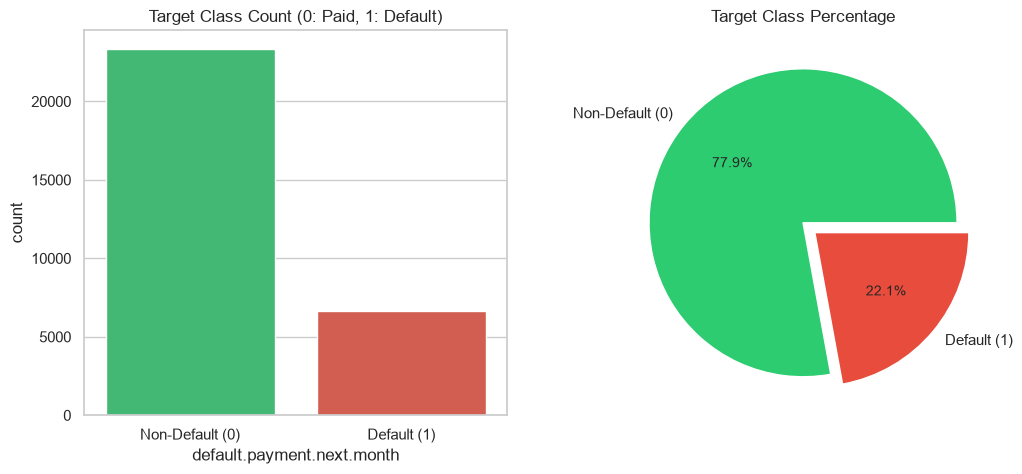

Class Counts:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Class Percentages:
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [3]:
target_col = 'default.payment.next.month' if 'default.payment.next.month' in df.columns else 'default_payment_next_month'

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.countplot(x=target_col, data=df, ax=ax[0], palette=['#2ecc71', '#e74c3c'])
ax[0].set_title('Target Class Count (0: Paid, 1: Default)')
ax[0].set_xticklabels(['Non-Default (0)', 'Default (1)'])

# Pie Chart
df[target_col].value_counts().plot.pie(
    autopct='%1.1f%%', 
    ax=ax[1], 
    colors=['#2ecc71', '#e74c3c'], 
    labels=['Non-Default (0)', 'Default (1)'], 
    explode=(0, 0.1)
)
ax[1].set_title('Target Class Percentage')
ax[1].set_ylabel('')

plt.show()

print("Class Counts:")
print(df[target_col].value_counts())
print("\nClass Percentages:")
print(df[target_col].value_counts(normalize=True) * 100)

Demographics & Categorical Analysis

C:\Users\omar yassen\AppData\Local\Temp\ipykernel_21168\2952611405.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(['Male', 'Female'])
C:\Users\omar yassen\AppData\Local\Temp\ipykernel_21168\2952611405.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 1].set_xticklabels(['Grad School', 'University', 'High School', 'Others'])
C:\Users\omar yassen\AppData\Local\Temp\ipykernel_21168\2952611405.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 0].set_xticklabels(['Married', 'Single', 'Others'])


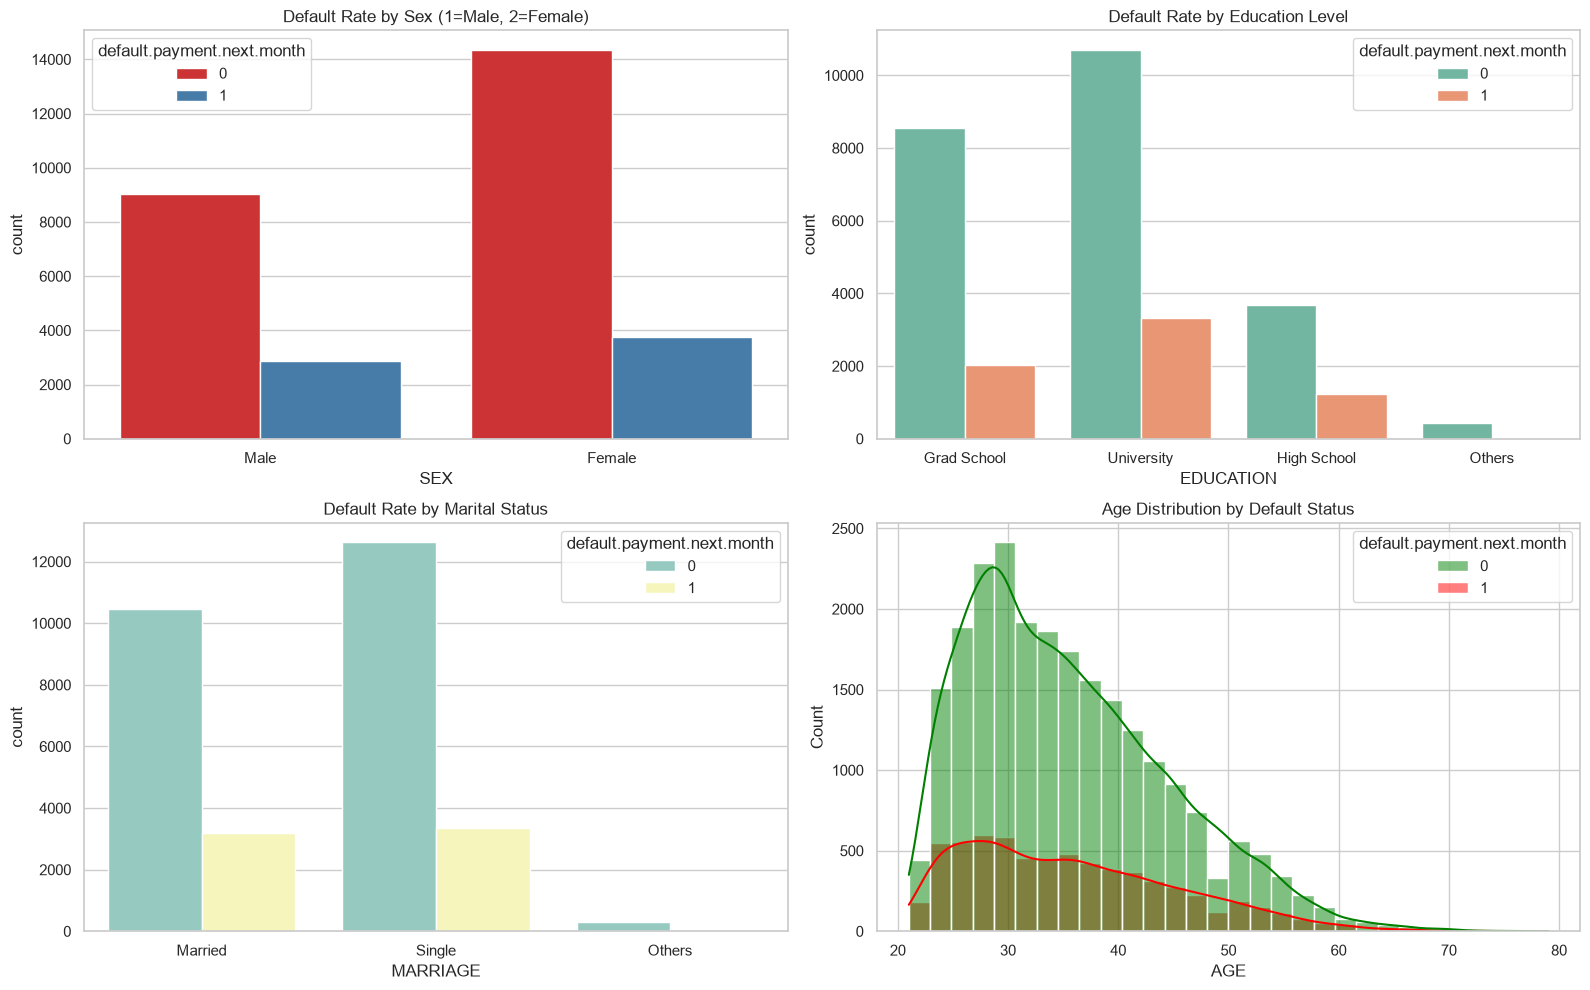

In [4]:
# Cleaning anomaly categories for visualization
df_clean = df.copy()
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sex Distribution vs Default
sns.countplot(x='SEX', hue=target_col, data=df_clean, ax=axes[0, 0], palette='Set1')
axes[0, 0].set_title('Default Rate by Sex (1=Male, 2=Female)')
axes[0, 0].set_xticklabels(['Male', 'Female'])

# 2. Education Distribution vs Default
sns.countplot(x='EDUCATION', hue=target_col, data=df_clean, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Default Rate by Education Level')
axes[0, 1].set_xticklabels(['Grad School', 'University', 'High School', 'Others'])

# 3. Marriage Distribution vs Default
sns.countplot(x='MARRIAGE', hue=target_col, data=df_clean, ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Default Rate by Marital Status')
axes[1, 0].set_xticklabels(['Married', 'Single', 'Others'])

# 4. Age Distribution with KDE
sns.histplot(data=df_clean, x='AGE', hue=target_col, kde=True, ax=axes[1, 1], palette=['green', 'red'], bins=30)
axes[1, 1].set_title('Age Distribution by Default Status')

plt.tight_layout()
plt.show()

Repayment Status Analysis (PAY_0 to PAY_6)

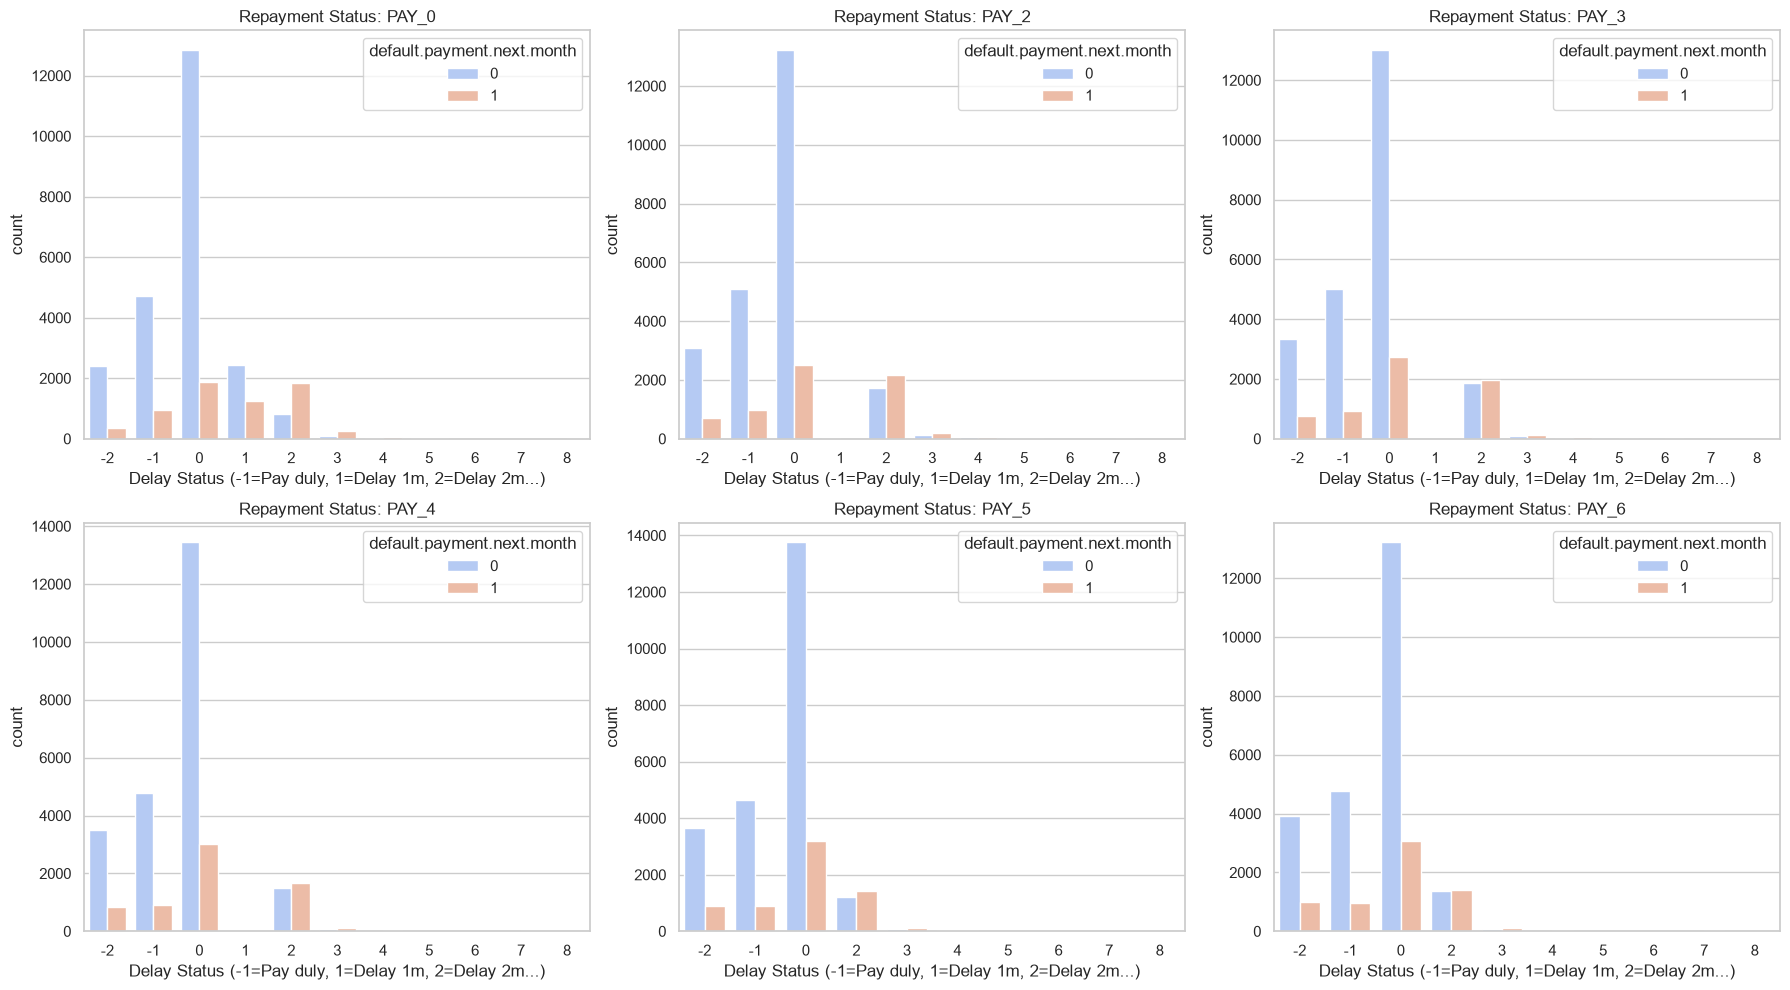

In [5]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    sns.countplot(x=col, hue=target_col, data=df, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Repayment Status: {col}')
    axes[i].set_xlabel('Delay Status (-1=Pay duly, 1=Delay 1m, 2=Delay 2m...)')

plt.tight_layout()
plt.show()

Financial Features Analysis (Bill Amounts & Payment Amounts)

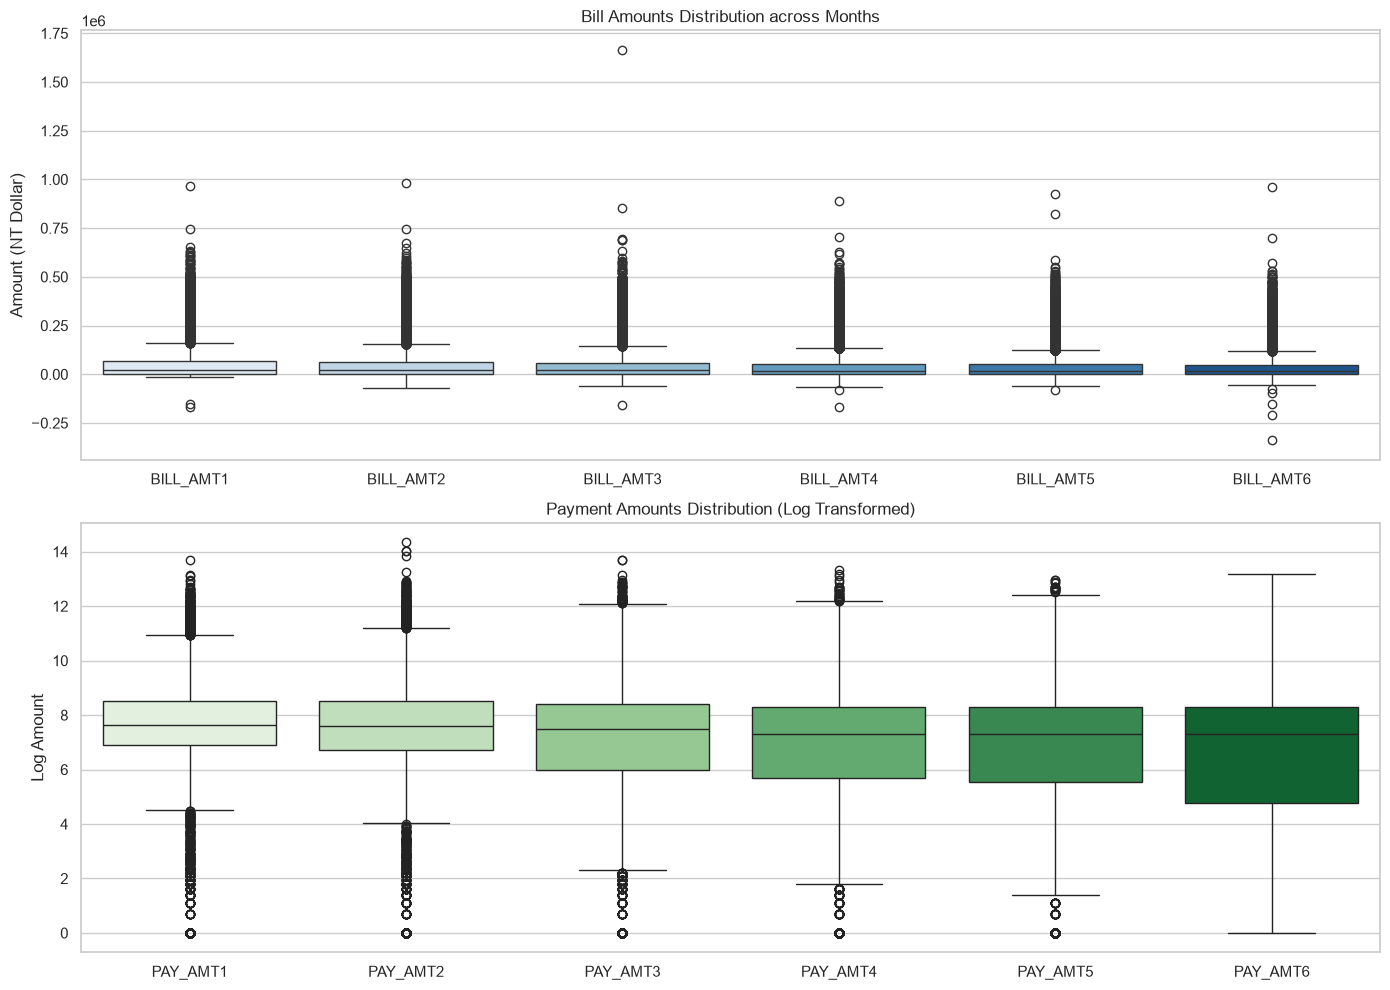

In [6]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Boxplot for Bill Amounts
sns.boxplot(data=df[bill_cols], ax=axes[0], palette='Blues')
axes[0].set_title('Bill Amounts Distribution across Months')
axes[0].set_ylabel('Amount (NT Dollar)')

# 2. Boxplot for Pay Amounts (Log Scale for readability)
sns.boxplot(data=np.log1p(df[pay_amt_cols]), ax=axes[1], palette='Greens')
axes[1].set_title('Payment Amounts Distribution (Log Transformed)')
axes[1].set_ylabel('Log Amount')

plt.tight_layout()
plt.show()

Correlation Matrix & Heatmap

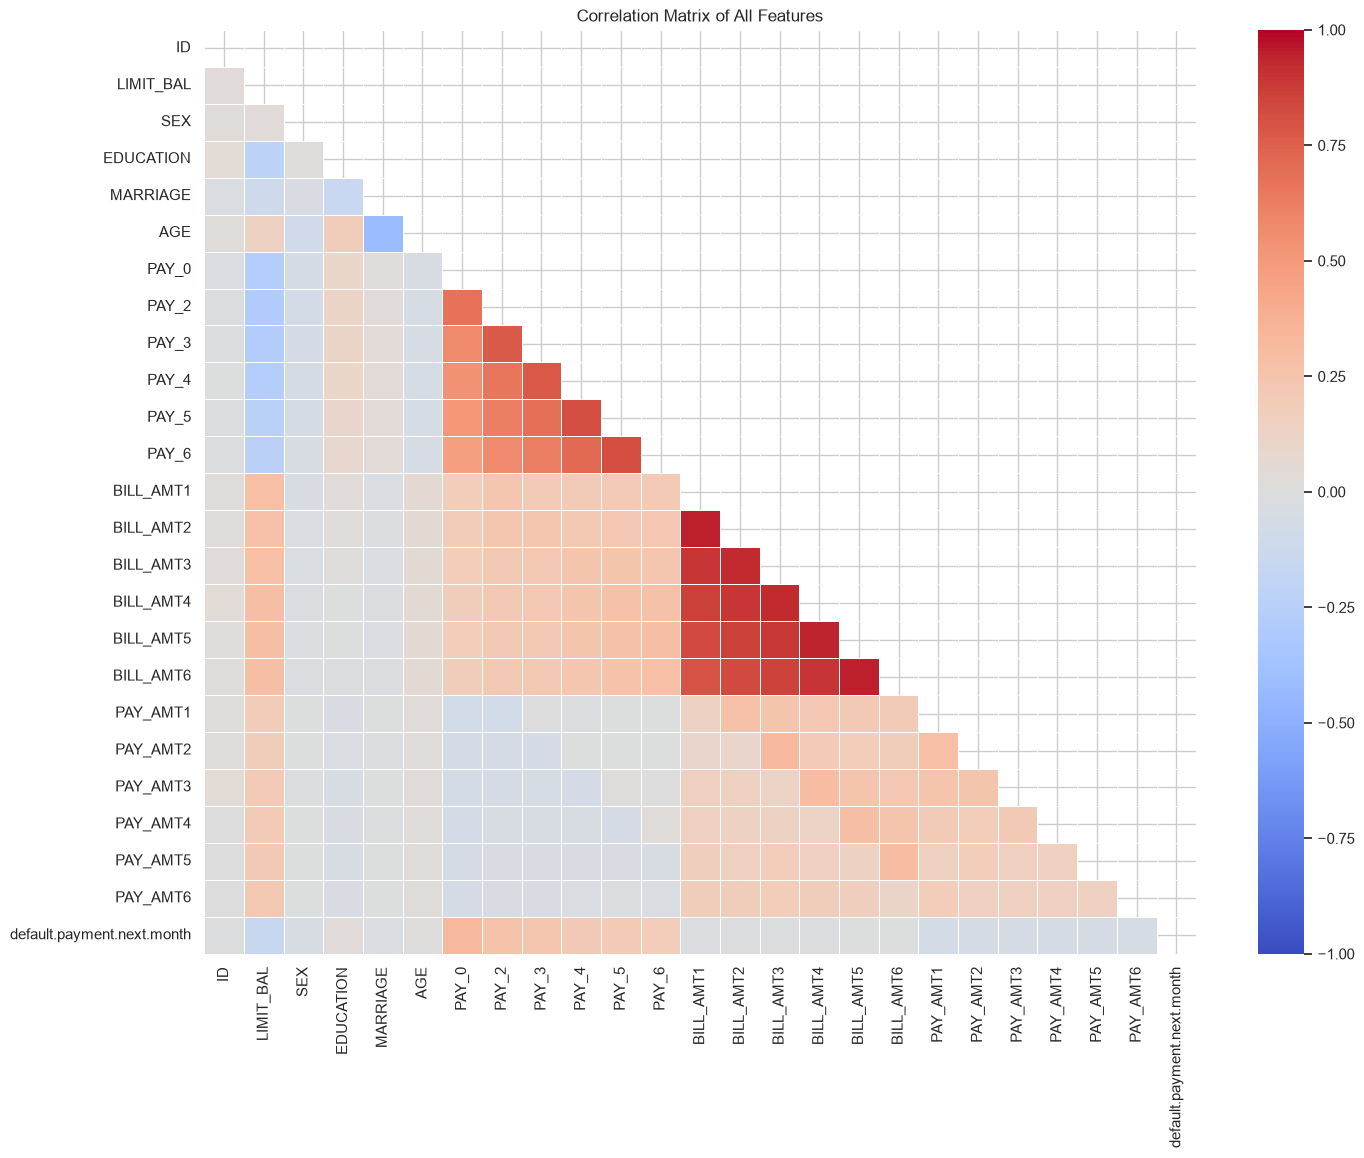

Top Correlations with Target:
default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.15

In [7]:
plt.figure(figsize=(16, 12))
corr = df.corr()

# Mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, annot=False, linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.show()

# Correlation of features with Target
print("Top Correlations with Target:")
print(corr[target_col].sort_values(ascending=False))